# Processing Inhibitor Data

____

In [40]:
from pathlib import Path
current_dir = Path().resolve()
from microlive.imports import *
from microlive import microscopy as mi
main_dir = Path().resolve().parent
one_drive_dir = mi.Utilities.get_one_drive_dir()
import inhibitors as INH

## Data Configuration
___

In [41]:
# Loading data
        #RMS External Drive Location:    'E:\Co-translational folding (CoF) paper\Fig 4_Fast_Har analysis'
        #Ning Zhao OneDrive Location:    '...General - Zhao (NZ) Lab\Zhao lab shared folder\Our papers\co-translational folding paper\Fig 4\Fig 4_Harringtonine analysis_GFPFast'


# ── Data Path ─────────────────────────────────────────────
# data_dir = one_drive_dir / 'General - Zhao (NZ) Lab' / 'Gui RMS Analyses' / 'Har' #Onedrive
data_dir = Path(r'E:/Co-translational folding (CoF) paper/Fig 4_Har_Fast/non pb')
 
# elongation rates
def elongation_rates (gene_length,dwell_time ):
    ke = gene_length/ dwell_time
    return np.round(ke,3)

# ── Processing Parameters ─────────────────────────────────
inhibitor_frame_index = 4  # 0-indexed: frame when treatment was applied
use_sem = True
show_summary = True
show_individual_trajectories = False
max_percentage_threshold_after_treatment = None #0.5
threshold_percentage_for_runoff = 0.1
use_sigmoidal_fit = True
# ── Plotting Parameters ───────────────────────────────────
figsize = (5, 4)
ylims = (-0.1, 1.3)
xlims = (-5, 54.5)                              # limits needs to be set to include more than the fit_end_idx frames for the x-axis
fit_start_idx=inhibitor_frame_index          # int – fit range start (default: inh frame)
#fit_end_idx=14                               # int – fit range end (default: last frame) linear fits for pRS027=11, pRS048=14, pRS038=XX
results_folder = Path('E:/Co-translational folding (CoF) paper/Fig 4_Har graphs_fast')  # Set to a Path to save plots

## HA Channel (pRS027; 4xGFPfast)

── Linear Fit ──
  a (slope): -0.1201
  b (intercept): 0.9761
  Iss (baseline): 0.1838
  a_err: 0.0032
  b_err: 0.0149
  t½:      3.30 min
  τ_runoff (2×t½): 6.60 min
  χ²_red:  4.1028  (dof=6)
  R²:      0.9713  (n=8)


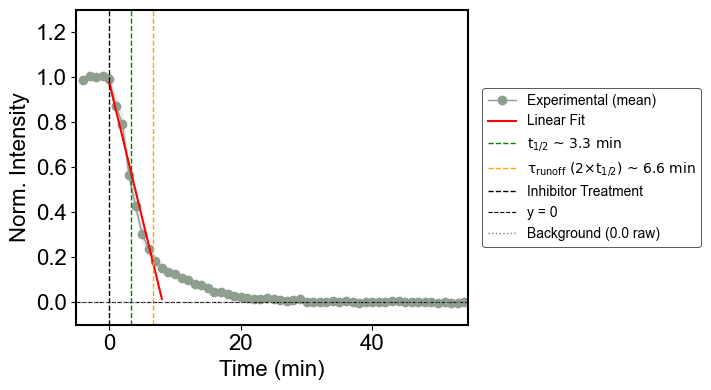

responding_indices_pRS027_HA: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25]
number of responding trajectories for pRS027_HA: 26


In [42]:
substring_in_data_dir = 'pRS027'
selected_field = 'spot_int_ch_0'
plot_name = 'pRS027_HA'
 
responding_indices_pRS027_HA, frames_pRS027_HA, intensities_pRS027_HA, _, _, _, _, _ = INH.process_inhibitor_data(
    data_dir, inhibitor_frame_index, substring_in_data_dir, selected_field,
    use_sem, show_summary, max_percentage_threshold_after_treatment,remove_frame_at_inhibitor_application=False,
)
 
 
results=INH.plot_inhibitor(
    frames_pRS027_HA,                                # np.ndarray – time array
    intensities_pRS027_HA,                           # np.ndarray – 2D (cells × frames)
    inhibitor_frame_index,                           # int – treatment frame index
    results_folder=results_folder,                   # Path – save location
    plot_name=plot_name,                             # str – filename suffix
    responding_indices=responding_indices_pRS027_HA, # list – which cells to include
    figsize=figsize,                                  # tuple
    use_sem=True,                                    # bool – SEM vs SD for error band
    show_individual_trajectories=False,               # bool – gray individual traces
    ylims=ylims,                                  # tuple – y-axis limits
    xlims=xlims,                                  # tuple – x-axis limits
    y_label='Norm. Intensity',                       # str
    treatment_label='Inhibitor',                     # str – label for treatment line
    show_treatment_line=True,                        # bool – vertical line at t=0
    fit_model='linear',                           # 'linear'|'exponential'|'heaviside'|None
    fit_start_idx=fit_start_idx,                     # int – fit range start (default: inh frame)
    fit_end_idx=11,                                 # int – fit range end (default: last frame)
    show_fit=True,                                   # bool – overlay fitted curve
    show_runoff_time=True,                           # bool – draw t½ and τ_runoff lines
    runoff_fraction=0.9,                            # float – threshold for run-off (0.95 = 95%)
    remove_background_intensity=True,               # subtract background & rescale to 0-1
    background_frames=10,                           # use last 10 frames within xlims window
    show_background_line=True,                      # dashed line at background level
    show_zero_y_axis=True,                          # dashed line at y = 0
    colors='#8E9E8F',
)
 
print("responding_indices_pRS027_HA:", responding_indices_pRS027_HA)
print("number of responding trajectories for pRS027_HA:", len(responding_indices_pRS027_HA))
 
 
# Access each dataset by index
#print('run-off time dataset 0:', results['t_runoff'])

In [43]:
# pRS027 gene length
g_length = 1826  # gene length total
half_tag = 167   # gene length total
g_length_effective = g_length-half_tag # gene_length_without_half_tag
print('Effective gene length, removing half of the length of the tag region:', g_length_effective)
 
# Recovered dwell times:
dwell_time_min =  results['t_runoff'] - 1     # removing one minute to account for drug diffusion
dwell_time_sec = dwell_time_min*60
 

 
elongation_rate = elongation_rates (g_length_effective,dwell_time_sec)
print('Elongation rate: ', elongation_rate, 'aa/sec')

Effective gene length, removing half of the length of the tag region: 1659
Elongation rate:  4.941 aa/sec


## HA Channel (pRS048; Xbp1u-4xGFPfast)
___

── Linear Fit ──
  a (slope): -0.0580
  b (intercept): 0.9176
  Iss (baseline): 0.3960
  a_err: 0.0021
  b_err: 0.0133
  t½:      4.50 min
  τ_runoff (2×t½): 8.99 min
  χ²_red:  2.9763  (dof=9)
  R²:      0.9732  (n=11)


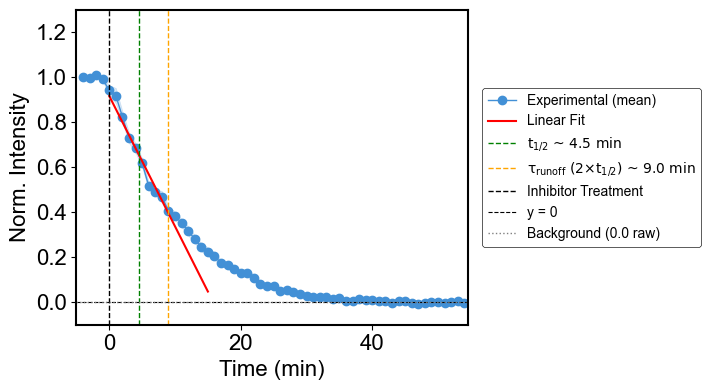

responding_indices_pRS048_HA: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21]
number of responding trajectories for pRS048_HA: 22


In [44]:
substring_in_data_dir = 'pRS048'
selected_field = 'spot_int_ch_0'
plot_name = 'pRS048_multi fit'
 
responding_indices_pRS048_HA, frames_pRS048_HA, intensities_pRS048_HA, _, _, _, _, _ = INH.process_inhibitor_data(
    data_dir, inhibitor_frame_index, substring_in_data_dir, selected_field,
    use_sem, show_summary, max_percentage_threshold_after_treatment,remove_frame_at_inhibitor_application=False,
)
 
 
results=INH.plot_inhibitor(
    frames_pRS048_HA,                                # np.ndarray – time array
    intensities_pRS048_HA,                           # np.ndarray – 2D (cells × frames)
    inhibitor_frame_index,                           # int – treatment frame index
    results_folder=results_folder,                   # Path – save location
    plot_name=plot_name,                             # str – filename suffix
    responding_indices=responding_indices_pRS048_HA, # list – which cells to include
    figsize=figsize,                                  # tuple
    use_sem=True,                                    # bool – SEM vs SD for error band
    show_individual_trajectories=False,               # bool – gray individual traces
    ylims=ylims,                                  # tuple – y-axis limits
    xlims=xlims,                                  # tuple – x-axis limits
    y_label='Norm. Intensity',                       # str
    treatment_label='Inhibitor',                     # str – label for treatment line
    show_treatment_line=True,                        # bool – vertical line at t=0
    fit_model='linear',                           # 'linear'|'exponential'|'heaviside'|None
    fit_start_idx=fit_start_idx,                     # int – fit range start (default: inh frame)
    fit_end_idx=14,                                 # int – fit range end (default: last frame)
    show_fit=True,                                   # bool – overlay fitted curve
    show_runoff_time=True,                           # bool – draw t½ and τ_runoff lines
    runoff_fraction=0.9,                            # float – threshold for run-off (0.95 = 95%)
    remove_background_intensity=True,               # subtract background & rescale to 0-1
    background_frames=10,                           # use last 10 frames within xlims window
    show_background_line=True,                      # dashed line at background level
    show_zero_y_axis=True,                          # dashed line at y = 0
    colors='#4290D6',
)
 
print("responding_indices_pRS048_HA:", responding_indices_pRS048_HA)
print("number of responding trajectories for pRS048_HA:", len(responding_indices_pRS048_HA))
 
 
# Access each dataset by index
#print('run-off time dataset 0:', results['t_runoff'])

In [45]:
# pRS048 gene length
g_length = 1855  # gene length total
half_tag = 167   # gene length total
g_length_effective = g_length-half_tag # gene_length_without_half_tag
print('Effective gene length, removing half of the length of the tag region:', g_length_effective)
 
# Recovered dwell times:
dwell_time_min =  results['t_runoff'] - 1     # removing one minute to account for drug diffusion
dwell_time_sec = dwell_time_min*60
 

 
elongation_rate = elongation_rates (g_length_effective,dwell_time_sec)
print('Elongation rate: ', elongation_rate, 'aa/sec')

Effective gene length, removing half of the length of the tag region: 1688
Elongation rate:  3.52 aa/sec


## HA Channel (pRS038; 4xGFPfast-Xbp1u)
___

── Linear Fit ──
  a (slope): -0.0251
  b (intercept): 0.9187
  Iss (baseline): 0.2247
  a_err: 0.0004
  b_err: 0.0068
  t½:      13.80 min
  τ_runoff (2×t½): 27.61 min
  χ²_red:  2.0110  (dof=30)
  R²:      0.9876  (n=32)


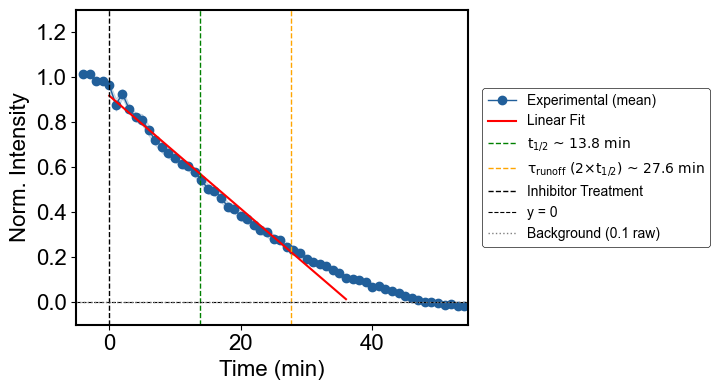

responding_indices_pRS038_HA: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]
number of responding trajectories for pRS038_HA: 24


In [46]:
substring_in_data_dir = 'pRS038'
selected_field = 'spot_int_ch_0'
plot_name = 'pRS038_HA'
 
responding_indices_pRS038_HA, frames_pRS038_HA, intensities_pRS038_HA, _, _, _, _, _ = INH.process_inhibitor_data(
    data_dir, inhibitor_frame_index, substring_in_data_dir, selected_field,
    use_sem, show_summary, max_percentage_threshold_after_treatment,remove_frame_at_inhibitor_application=False,
)
 
 
results=INH.plot_inhibitor(
    frames_pRS038_HA,                                # np.ndarray – time array
    intensities_pRS038_HA,                           # np.ndarray – 2D (cells × frames)
    inhibitor_frame_index,                           # int – treatment frame index
    results_folder=results_folder,                   # Path – save location
    plot_name=plot_name,                             # str – filename suffix
    responding_indices=responding_indices_pRS038_HA, # list – which cells to include
    figsize=figsize,                                  # tuple
    use_sem=True,                                    # bool – SEM vs SD for error band
    show_individual_trajectories=False,               # bool – gray individual traces
    ylims=ylims,                                  # tuple – y-axis limits
    xlims=xlims,                                  # tuple – x-axis limits
    y_label='Norm. Intensity',                       # str
    treatment_label='Inhibitor',                     # str – label for treatment line
    show_treatment_line=True,                        # bool – vertical line at t=0
    fit_model='linear',                           # 'linear'|'exponential'|'heaviside'|None
    fit_start_idx=fit_start_idx,                     # int – fit range start (default: inh frame)
    fit_end_idx=35,                                 # int – fit range end (default: last frame)
    show_fit=True,                                   # bool – overlay fitted curve
    show_runoff_time=True,                           # bool – draw t½ and τ_runoff lines
    runoff_fraction=0.9,                            # float – threshold for run-off (0.95 = 95%)
    remove_background_intensity=True,               # subtract background & rescale to 0-1
    background_frames=10,                           # use last 10 frames within xlims window
    show_background_line=True,                      # dashed line at background level
    show_zero_y_axis=True,                          # dashed line at y = 0
    colors='#215F9A',
)
 
print("responding_indices_pRS038_HA:", responding_indices_pRS038_HA)
print("number of responding trajectories for pRS038_HA:", len(responding_indices_pRS038_HA))

# Access each dataset by index
#print('run-off time dataset 0:', results['t_runoff'])

In [47]:
# pRS038 gene length
g_length = 1852  # gene length total
half_tag = 167   # gene length total
g_length_effective = g_length-half_tag # gene_length_without_half_tag
print('Effective gene length, removing half of the length of the tag region:', g_length_effective)
 
# Recovered dwell times:
dwell_time_min =  results['t_runoff'] - 1     # removing one minute to account for drug diffusion
dwell_time_sec = dwell_time_min*60
 

 
elongation_rate = elongation_rates (g_length_effective,dwell_time_sec)
print('Elongation rate: ', elongation_rate, 'aa/sec')

Effective gene length, removing half of the length of the tag region: 1685
Elongation rate:  1.055 aa/sec


## Multi-Reporter Comparison
___

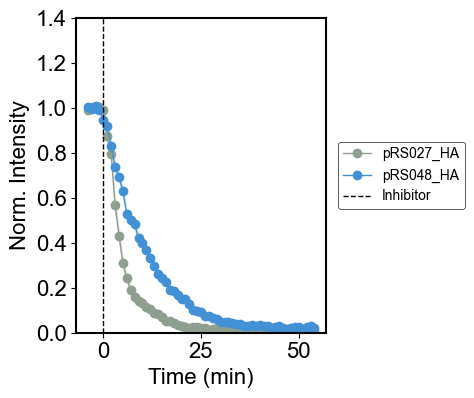

responding_indices_pRS027_HA: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25]
number of responding trajectories for pRS027_HA: 26
responding_indices_pRS048_HA: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21]
number of responding trajectories for pRS048_HA: 22


In [48]:
INH.plot_multiple_inhibitors(
    [frames_pRS027_HA, frames_pRS048_HA,],
    [intensities_pRS027_HA, intensities_pRS048_HA],
    inhibitor_frame_index,
    responding_indices_list=[responding_indices_pRS027_HA, responding_indices_pRS048_HA],
    colors=['#8E9E8F', '#4290D6'],    #215F9A (xbp1u), #1B4F7F (darker), #4290D6 (lighter), #8E9E8F (sfGFP), #929000 (GFPuv)
    legend_labels=['pRS027_HA', 'pRS048_HA'],
    plot_name='HT_pRS027_vs_pRS048',
    #threshold_percentage_for_runoff=-0.4,
    ylims = (0, 1.4),
    figsize=figsize,
    use_sem=use_sem,
    show_individual_trajectories=show_individual_trajectories,
    results_folder=results_folder,
)

print("responding_indices_pRS027_HA:", responding_indices_pRS027_HA)
print("number of responding trajectories for pRS027_HA:", len(responding_indices_pRS027_HA))
print("responding_indices_pRS048_HA:", responding_indices_pRS048_HA)
print("number of responding trajectories for pRS048_HA:", len(responding_indices_pRS048_HA))

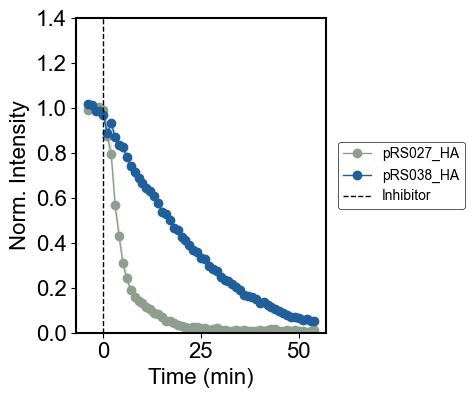

responding_indices_pRS027_HA: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25]
number of responding trajectories for pRS027_HA: 26
responding_indices_pRS038_HA: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]
number of responding trajectories for pRS038_HA: 24


In [49]:
INH.plot_multiple_inhibitors(
    [frames_pRS027_HA, frames_pRS038_HA,],
    [intensities_pRS027_HA, intensities_pRS038_HA],
    inhibitor_frame_index,
    responding_indices_list=[responding_indices_pRS027_HA, responding_indices_pRS038_HA],
    colors=['#8E9E8F', '#215F9A'], #215F9A (xbp1u), #1B4F7F (darker), #4290D6 (lighter), #8E9E8F (sfGFP), #929000 (GFPuv)
    legend_labels=['pRS027_HA', 'pRS038_HA'],
    plot_name='HT_pRS027_vs_pRS038',
    #threshold_percentage_for_runoff=-0.4,
    ylims = (0, 1.4),
    figsize=figsize,
    use_sem=use_sem,
    show_individual_trajectories=show_individual_trajectories,
    results_folder=results_folder,
)

print("responding_indices_pRS027_HA:", responding_indices_pRS027_HA)
print("number of responding trajectories for pRS027_HA:", len(responding_indices_pRS027_HA))
print("responding_indices_pRS038_HA:", responding_indices_pRS038_HA)
print("number of responding trajectories for pRS038_HA:", len(responding_indices_pRS038_HA))

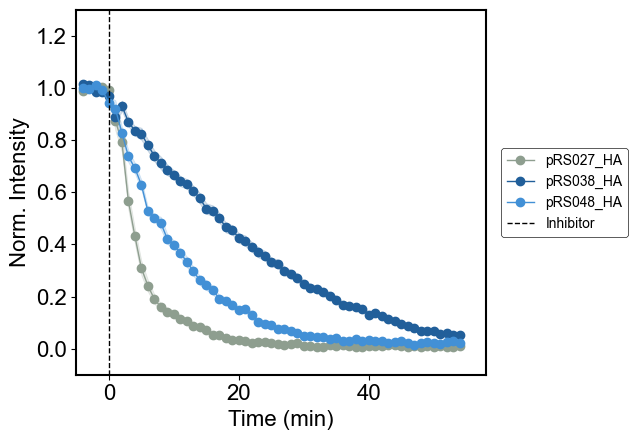

responding_indices_pRS027_HA: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25]
number of responding trajectories for pRS027_HA: 26
responding_indices_pRS038_HA: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]
number of responding trajectories for pRS038_HA: 24
responding_indices_pRS048_HA: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21]
number of responding trajectories for pRS048_HA: 22


In [50]:
INH.plot_multiple_inhibitors(
    [frames_pRS027_HA, frames_pRS038_HA, frames_pRS048_HA],
    [intensities_pRS027_HA, intensities_pRS038_HA, intensities_pRS048_HA],
    inhibitor_frame_index,
    responding_indices_list=[responding_indices_pRS027_HA, responding_indices_pRS038_HA, responding_indices_pRS048_HA],
    colors=['#8E9E8F', '#215F9A','#4290D6'], #215F9A (xbp1u), #1B4F7F (darker), #4290D6 (lighter), #8E9E8F (sfGFP), #929000 (GFPuv)
    legend_labels=['pRS027_HA', 'pRS038_HA', 'pRS048_HA'],
    plot_name='HT_multi_all',
    #threshold_percentage_for_runoff=-0.4,
    ylims=ylims,
    xlims=(-5, 58),
    figsize=(6.5, 4.5),
    show_individual_trajectories=show_individual_trajectories,
    results_folder=results_folder,
)

print("responding_indices_pRS027_HA:", responding_indices_pRS027_HA)
print("number of responding trajectories for pRS027_HA:", len(responding_indices_pRS027_HA))
print("responding_indices_pRS038_HA:", responding_indices_pRS038_HA)
print("number of responding trajectories for pRS038_HA:", len(responding_indices_pRS038_HA))
print("responding_indices_pRS048_HA:", responding_indices_pRS048_HA)
print("number of responding trajectories for pRS048_HA:", len(responding_indices_pRS048_HA))